### 1.1. Xử lí dữ liệu


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# =======================================================
# PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU
# =======================================================
# BƯỚC 1: ĐỌC VÀ MÔ TẢ DỮ LIỆU
# Đọc file CSV
df = pd.read_csv('E:\\smartphones_data.csv.csv')

# Kiểm tra kích thước và liệt kê các cột
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nDanh sách các cột:")
print(df.columns.tolist())

# Kiểm tra kiểu dữ liệu
print("\nThông tin kiểu dữ liệu:")
print(df.info())

Kích thước ban đầu: 3260 dòng, 20 cột

Danh sách các cột:
['brand_name', 'Name', 'Price', 'RAM', 'OS', 'storage', 'Battery_cap', 'has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g', 'processor_brand', 'num_core', 'primery_rear_camera', 'Num_Rear_Cameras', 'primery_front_camera', 'num_front_camera', 'display_size(inch)', 'refresh_rate(hz)', 'display_types']

Thông tin kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 3260 entries, 0 to 3259
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand_name            3260 non-null   str    
 1   Name                  3260 non-null   str    
 2   Price                 3260 non-null   int64  
 3   RAM                   3260 non-null   float64
 4   OS                    3260 non-null   str    
 5   storage               3260 non-null   float64
 6   Battery_cap           3260 non-null   int64  
 7   has_fast_charging     3260 non-null   str    
 

In [2]:
df = df.drop_duplicates()
print(f"\nKích thước sau khi xóa dữ liệu trùng lặp: {df.shape[0]} dòng, {df.shape[1]} cột")


Kích thước sau khi xóa dữ liệu trùng lặp: 3260 dòng, 20 cột


In [3]:
# BƯỚC 2: PHÁT HIỆN VÀ XỬ LÝ DỮ LIỆU LỖI
print("\nSố lượng missing values trước khi xử lý:")
print(df.isnull().sum())


Số lượng missing values trước khi xử lý:
brand_name                 0
Name                       0
Price                      0
RAM                        0
OS                         0
storage                    0
Battery_cap                0
has_fast_charging          0
has_fingerprints         726
has_nfc                  726
has_5g                   726
processor_brand            0
num_core                 175
primery_rear_camera        0
Num_Rear_Cameras           0
primery_front_camera       0
num_front_camera           0
display_size(inch)         0
refresh_rate(hz)        1731
display_types              0
dtype: int64


In [4]:
# Xử lý giá trị thiếu (missing values)
# điền median (trung vị) cho các cột số và mode (yếu tố xuất hiện nhiều nhất) cho cột phân loại

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Xử lý giá trị không hợp lệ & dị thường
# Giá RAM, storage, Battery_cap không được âm hoặc bằng 0
df = df[(df['RAM'] > 0) & (df['storage'] > 0) & (df['Battery_cap'] > 0)]

# Số lượng camera không được bằng 0
df = df[(df['Num_Rear_Cameras'] > 0) & (df['num_front_camera'] > 0)]

# Kích thước màn hình <= 8 inch
df = df[df['display_size(inch)'] <= 8]


# Xử lý kiểu dữ liệu các biến Categorical Yes/No -> 1/0
binary_cols = ['has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Xử lý cột OS
# Gom thành 3 nhóm rõ ràng: 'android', 'ios', và 'other'
df['OS'] = df['OS'].str.lower()
df['OS'] = df['OS'].apply(lambda x: x if pd.notna(x) and x in ['android', 'ios'] else 'other')

In [5]:
# BƯỚC 3: CHUYỂN ĐỔI DỮ LIỆU VỀ DẠNG PHÙ HỢP

# Bỏ cột 'Name'
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

# One-Hot Encoding cho biến categorical: brand_name, processor_brand, display_types
cols_to_encode = ['brand_name', 'processor_brand', 'display_types', 'OS']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

# Ép kiểu boolean True/False từ get_dummies về dạng 1/0 (số nguyên)
for col in df.select_dtypes(include=['boolean']).columns:
    df[col] = df[col].astype(int)

In [6]:
# BƯỚC 4: CHUẨN HÓA GIÁ TRỊ
scaler = StandardScaler()

# Chỉ chuẩn hóa các cột Numeric đầu vào, không chuẩn hóa đầu ra (Price) và các cột Binary (0/1)
numeric_features_to_scale = [
    'RAM', 'storage', 'Battery_cap', 'num_core',
    'primery_rear_camera', 'Num_Rear_Cameras',
    'primery_front_camera', 'num_front_camera',
    'display_size(inch)', 'refresh_rate(hz)'
]

# Thực hiện chuẩn hóa Z-score: z = (x-mean)/s
df[numeric_features_to_scale] = scaler.fit_transform(df[numeric_features_to_scale])

print(f"\n Kích thước dữ liệu sau khi xử lí: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.head())


 Kích thước dữ liệu sau khi xử lí: 3259 dòng, 71 cột
    Price       RAM   storage  Battery_cap  has_fast_charging  \
0   34999  0.903491  0.126929     1.400004                  1   
1   21999  0.903491  0.126929     1.400004                  1   
2   27999  0.903491  0.126929     1.400004                  1   
3  129999  2.133784  1.137190     0.637884                  1   
4   22999  0.903491  0.126929     1.018944                  1   

   has_fingerprints  has_nfc  has_5g  num_core  primery_rear_camera  ...  \
0                 1        0       1  0.522724             0.590197  ...   
1                 1        0       1  0.522724             0.590197  ...   
2                 1        0       1  0.522724             0.590197  ...   
3                 1        1       1  0.522724             5.692910  ...   
4                 1        0       1  0.522724             0.590197  ...   

   processor_brand_tru-mediatek  processor_brand_unisoc  \
0                             0        

### 1.2. Phân tích, trực quan hóa và giảm chiều


Kích thước dữ liệu gốc: (3259, 70)


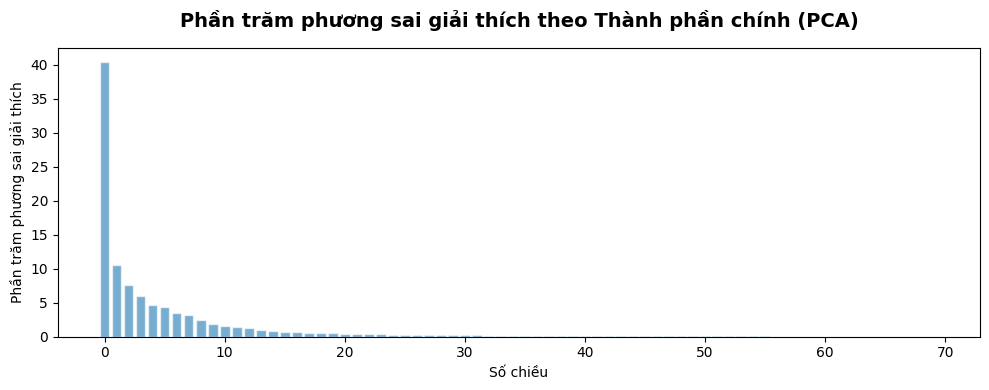

In [22]:
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')

# GIẢM CHIỀU BẰNG 2 PHƯƠNG PHÁP (PCA & LDA)
X = df.drop(columns=['Price'])
y = df['Price']

# Tạo y_class (phân loại giá thành 3 nhóm)
y_class = pd.qcut(df['Price'], q=3, labels=['Low', 'Medium', 'High'])
print(f"Kích thước dữ liệu gốc: {X.shape}")

# Giảm chiều bằng LDA (2 chiều)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y_class)


import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

plt.style.use('default')

pca_full = PCA(random_state=42)
pca_full.fit(X)

# Lấy mảng tỷ lệ phương sai của từng cột và nhân 100 để ra phần trăm (%)
explained_variance_pct = pca_full.explained_variance_ratio_ * 100

# Vẽ biểu đồ Bar Chart
plt.figure(figsize=(10, 4))

plt.bar(
    range(len(explained_variance_pct)),
    explained_variance_pct,
    alpha=0.6,
    color='tab:blue',
    edgecolor='white'
)

plt.xlabel('Số chiều')
plt.ylabel('Phần trăm phương sai giải thích')
plt.title('Phần trăm phương sai giải thích theo Thành phần chính (PCA)', fontsize=14, pad=15, fontweight='bold')

plt.tight_layout()
plt.show()

Số chiều chính xác cần để đạt >= 95% phương sai là: 23


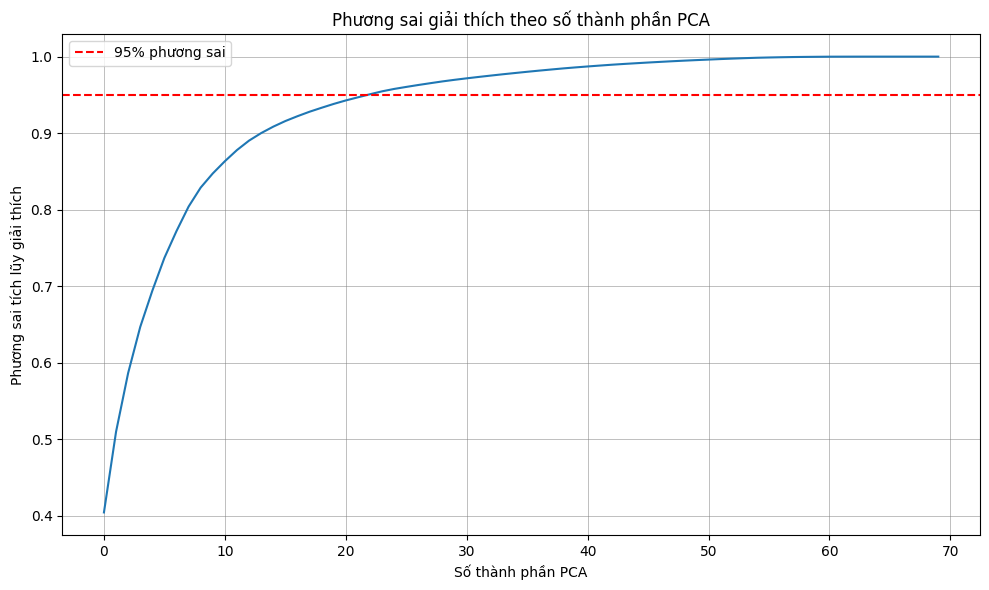

In [21]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Số chiều chính xác cần để đạt >= 95% phương sai là: {n_components_95}")

plt.figure(figsize=(10, 6))
plt.plot(range(len(cumulative_variance)), cumulative_variance, color='tab:blue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% phương sai')
plt.title('Phương sai giải thích theo số thành phần PCA')
plt.xlabel('Số thành phần PCA')
plt.ylabel('Phương sai tích lũy giải thích')
plt.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
plt.legend(loc='upper left')

# Hiển thị
plt.tight_layout()
plt.show()

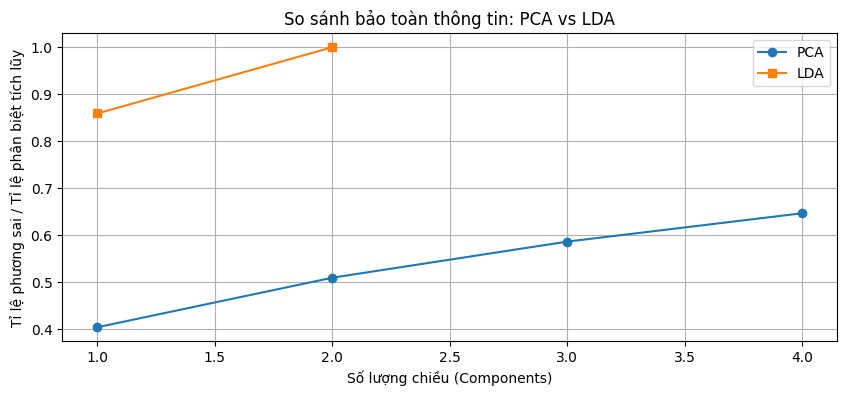

In [11]:
# Vẽ đồ thị Explained Variance
plt.figure(figsize=(10, 4))
plt.plot(range(1, 5), np.cumsum(pca.explained_variance_ratio_), marker='o', label='PCA')
plt.plot(range(1, 3), np.cumsum(lda.explained_variance_ratio_), marker='s', label='LDA')
plt.xlabel('Số lượng chiều (Components)')
plt.ylabel('Tỉ lệ phương sai / Tỉ lệ phân biệt tích lũy')
plt.title('So sánh bảo toàn thông tin: PCA vs LDA')
plt.legend()
plt.grid(True)
plt.show()

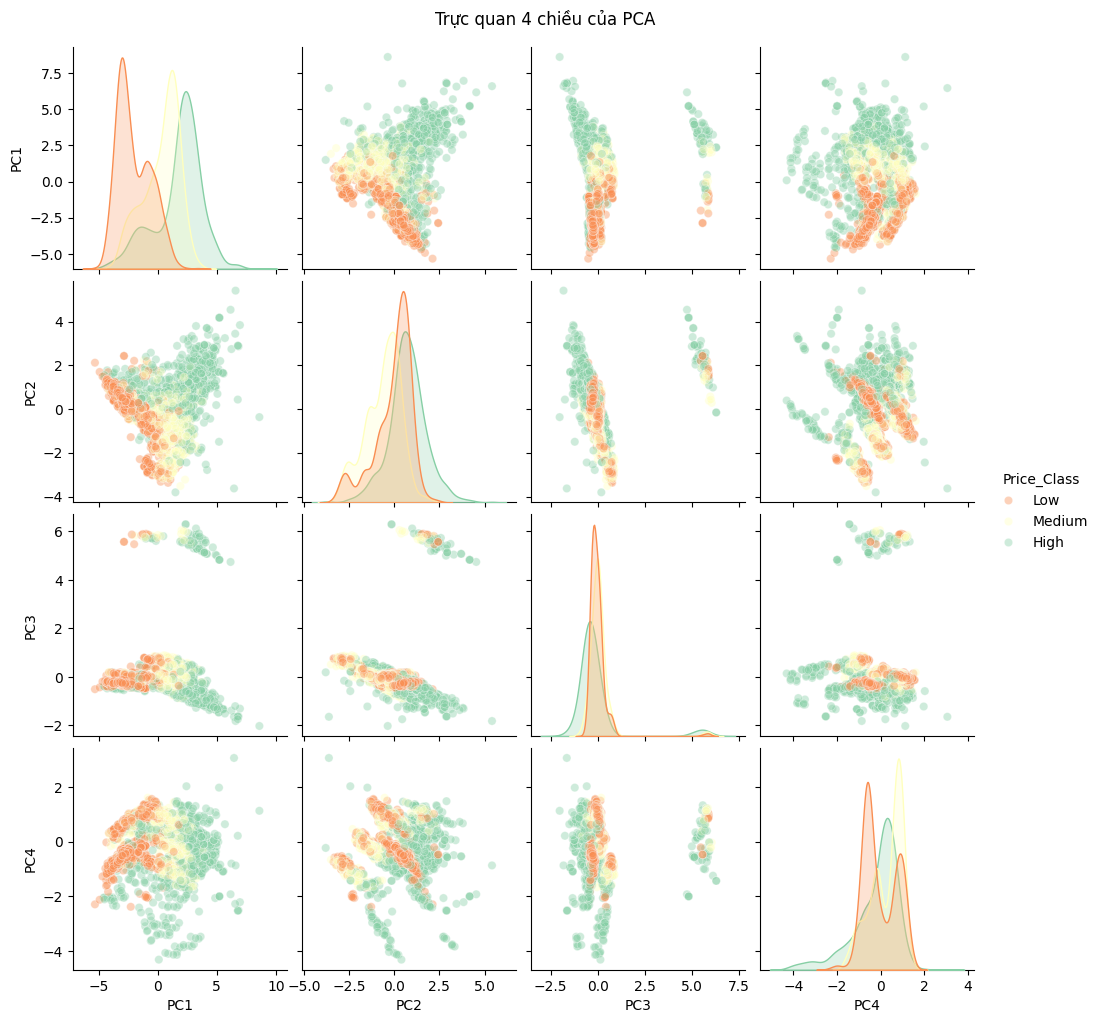

In [20]:
# TRỰC QUAN HÓA THEO 2 CẶP THÀNH PHẦN CHÍNH
# Pairplot cho PCA
df_pca = pd.DataFrame(X_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca['Price_Class'] = y_class.values
sns.pairplot(df_pca, hue='Price_Class', diag_kind='kde', plot_kws={'alpha': 0.4}, palette='Spectral')
plt.suptitle('Trực quan 4 chiều của PCA', y=1.02)
plt.show()

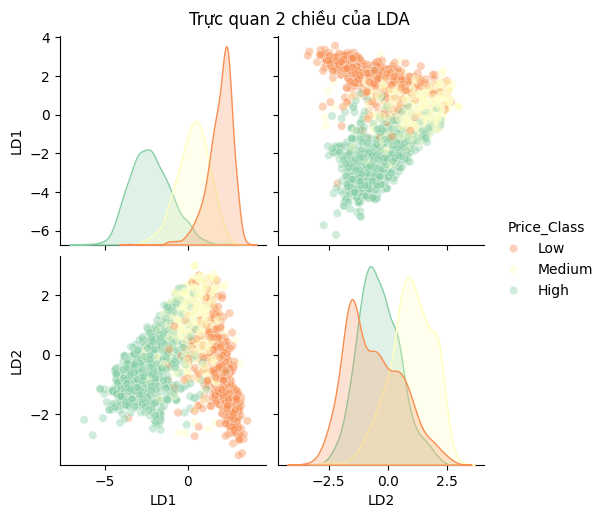

In [19]:
# Pairplot cho LDA
df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
df_lda['Price_Class'] = y_class.values
sns.pairplot(df_lda, hue='Price_Class', diag_kind='kde', plot_kws={'alpha': 0.4}, palette='Spectral')
plt.suptitle('Trực quan 2 chiều của LDA', y=1.02)
plt.show()

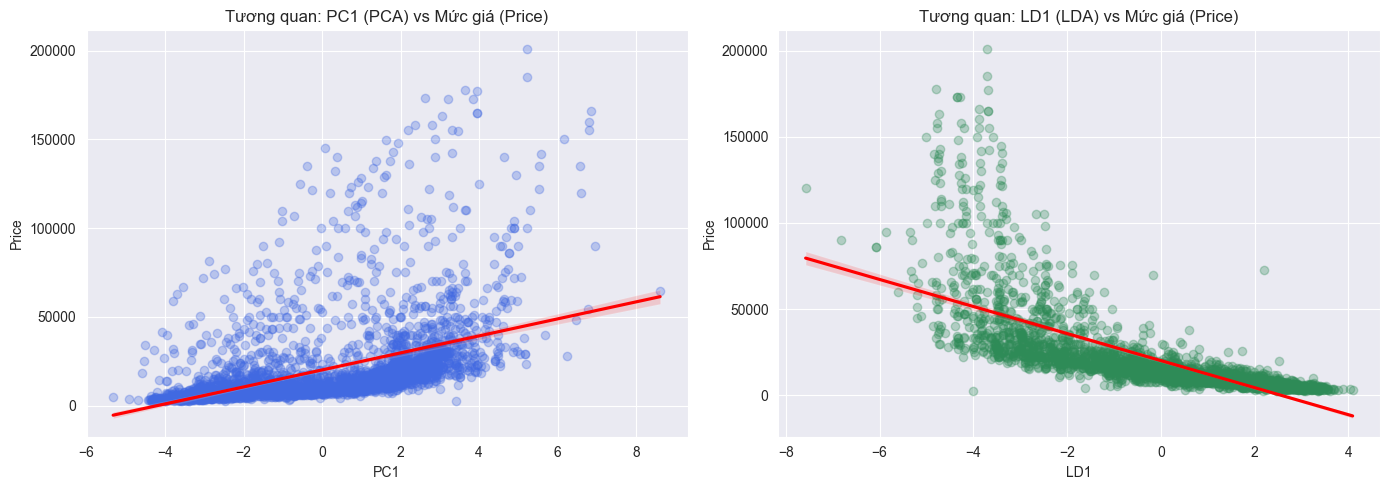

In [38]:
# MỐI QUAN HỆ CHIỀU CHÍNH VỚI ĐẦU RA (TƯƠNG QUAN TUYẾN TÍNH)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 của PCA với Price thực tế
sns.regplot(x=X_pca[:, 0], y=y, ax=axes[0], scatter_kws={'alpha':0.3, 'color': 'royalblue'}, line_kws={'color':'red'})
axes[0].set_title('Tương quan: PC1 (PCA) vs Mức giá (Price)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('Price')

# LD1 của LDA với Price thực tế
sns.regplot(x=X_lda[:, 0], y=y, ax=axes[1], scatter_kws={'alpha':0.3, 'color': 'seagreen'}, line_kws={'color':'red'})
axes[1].set_title('Tương quan: LD1 (LDA) vs Mức giá (Price)')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

### 1.3. Phân tích hồi quy



In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Dữ liệu PCA giảm 1/3 kích thước ban đầu
n_reduced = int(X.shape[1] / 3)
pca = PCA(n_components=n_reduced)
X_reduced = pca.fit_transform(X)
print(f"\n Số chiều sau khi giảm 1/3: {n_reduced}")
print(f"Phương sai giải thích: {pca.explained_variance_ratio_.sum()*100:.2f}%")

splits = [0.2, 0.3, 0.4] # test size ứng với 4:1, 7:3, 6:4
models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5)
}
saved_results = {}
print("\n--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---")
for split in splits:
    print(f"\n[Tỉ lệ train:test = {int((1-split)*10)}:{int((split*10))}]")
    # Chia cho dữ liệu gốc
    X_train_ori, X_test_ori, y_train, y_test = train_test_split(X, y, test_size=split, random_state=42)
    # Chia cho dữ liệu đã giảm chiều
    X_train_red, X_test_red, _, _ = train_test_split(X_reduced, y, test_size=split, random_state=42)

    for name, model in models.items():
        # Trên tập gốc
        model.fit(X_train_ori, y_train)
        pred_ori_train = model.predict(X_train_ori)
        pred_ori_test = model.predict(X_test_ori)
        r2_ori_train = r2_score(y_train, pred_ori_train)
        r2_ori_test = r2_score(y_test, pred_ori_test)
        mse_ori_train = mean_squared_error(y_train, pred_ori_train)
        mse_ori_test = mean_squared_error(y_test, pred_ori_test)

        # Trên tập giảm chiều
        model.fit(X_train_red, y_train)
        pred_red_test = model.predict(X_test_red)
        r2_red = r2_score(y_test, pred_red_test)
        mse_red = mean_squared_error(y_test, pred_red_test)

        print(f"{name:25s} | R2 gốc (Train/Test): {r2_ori_train:.2f}/{r2_ori_test:.2f} | R2 Giảm chiều: {r2_red:.2f}")

        # Lưu kết quả của trường hợp 7:3
        if split == 0.3:
            saved_results[name] = {
                "y_test": y_test,
                "y_pred": pred_ori_test
            }



 Số chiều sau khi giảm 1/3: 23
Phương sai giải thích: 95.08%

--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---

[Tỉ lệ train:test = 8:2]
Linear Regression         | R2 gốc (Train/Test): 0.80/0.76 | R2 Giảm chiều: 0.73
KNN (k=5)                 | R2 gốc (Train/Test): 0.91/0.82 | R2 Giảm chiều: 0.80

[Tỉ lệ train:test = 7:3]
Linear Regression         | R2 gốc (Train/Test): 0.81/0.75 | R2 Giảm chiều: 0.73
KNN (k=5)                 | R2 gốc (Train/Test): 0.91/0.79 | R2 Giảm chiều: 0.77

[Tỉ lệ train:test = 6:4]
Linear Regression         | R2 gốc (Train/Test): 0.81/0.77 | R2 Giảm chiều: 0.75
KNN (k=5)                 | R2 gốc (Train/Test): 0.90/0.82 | R2 Giảm chiều: 0.81


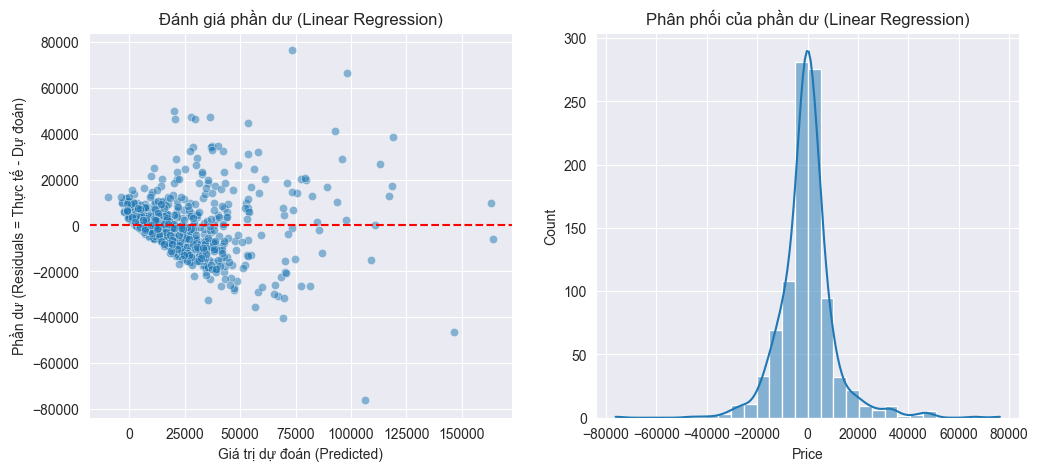

In [40]:
y_test_73 = saved_results["Linear Regression"]["y_test"]
y_pred_73 = saved_results["Linear Regression"]["y_pred"]

# 👉 Tính phần dư
residuals = y_test_73 - y_pred_73

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_73, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá trị dự đoán (Predicted)')
plt.ylabel('Phần dư (Residuals = Thực tế - Dự đoán)')
plt.title('Đánh giá phần dư (Linear Regression)')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Phân phối của phần dư (Linear Regression)')
plt.show()

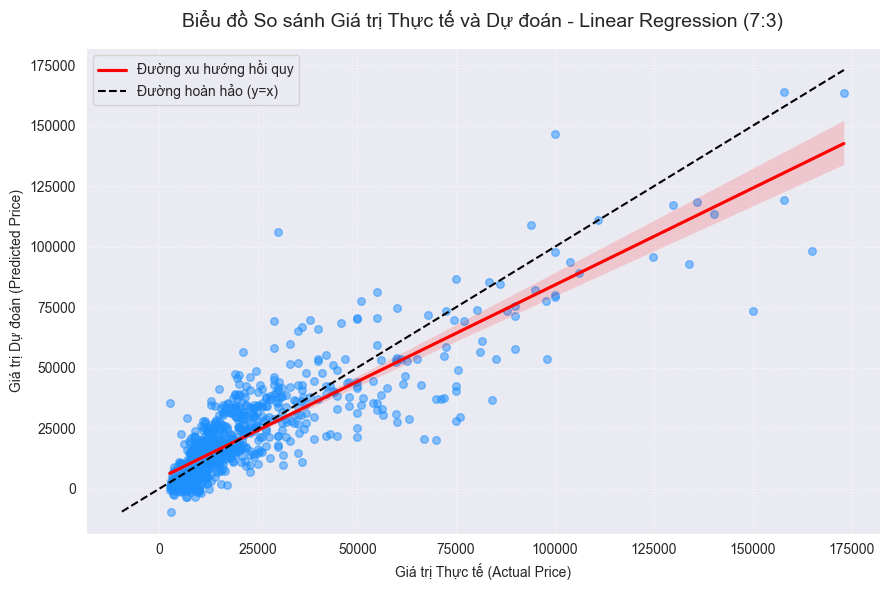

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# 1. Vẽ các điểm dữ liệu và đường xu hướng hồi quy
# x là Thực tế (Trục hoành), y là Dự đoán (Trục tung)
sns.regplot(
    x=y_test_73,
    y=y_pred_73,
    scatter_kws={'alpha': 0.5, 'color': 'dodgerblue', 's': 30},
    line_kws={'color': 'red', 'label': 'Đường xu hướng hồi quy'}
)

# 2. Vẽ đường hoàn hảo y = x (Nơi Dự đoán chính xác 100% bằng Thực tế)
min_val = min(y_test_73.min(), y_pred_73.min())
max_val = max(y_test_73.max(), y_pred_73.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Đường hoàn hảo (y=x)')

# 3. Thêm nhãn và tiêu đề
plt.xlabel('Giá trị Thực tế (Actual Price)')
plt.ylabel('Giá trị Dự đoán (Predicted Price)')
plt.title('Biểu đồ So sánh Giá trị Thực tế và Dự đoán - Linear Regression (7:3)', fontsize=14, pad=15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 4. Hiển thị đồ thị
plt.tight_layout()
plt.show()


 Số chiều sau khi giảm 1/3: 23
Phương sai giải thích: 95.08%

--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---

[Tỉ lệ train:test = 8:2]
Linear Regression         | R2 gốc (Train/Test): 0.80/0.76 | R2 Giảm chiều: 0.73
KNN (k=5)                 | R2 gốc (Train/Test): 0.91/0.82 | R2 Giảm chiều: 0.80

[Tỉ lệ train:test = 7:3]
Linear Regression         | R2 gốc (Train/Test): 0.81/0.75 | R2 Giảm chiều: 0.73
KNN (k=5)                 | R2 gốc (Train/Test): 0.91/0.79 | R2 Giảm chiều: 0.77

[Tỉ lệ train:test = 6:4]
Linear Regression         | R2 gốc (Train/Test): 0.81/0.77 | R2 Giảm chiều: 0.75
KNN (k=5)                 | R2 gốc (Train/Test): 0.90/0.82 | R2 Giảm chiều: 0.81


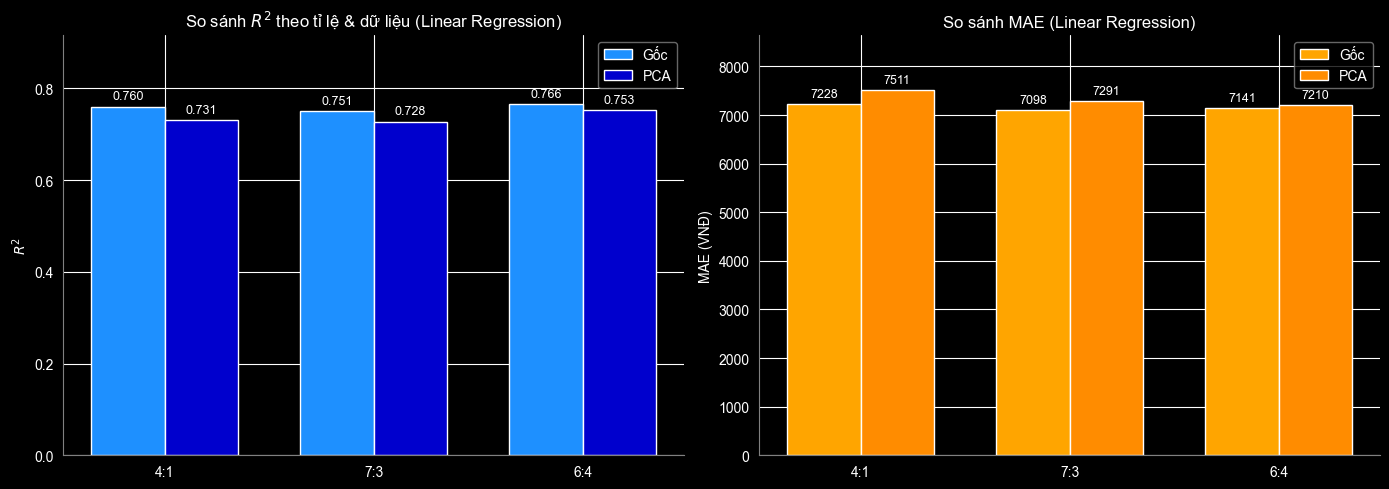

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu PCA giảm 1/3 kích thước ban đầu
n_reduced = int(X.shape[1] / 3)
pca = PCA(n_components=n_reduced, random_state=42) # Thêm random_state để cố định kết quả
X_reduced = pca.fit_transform(X)
print(f"\n Số chiều sau khi giảm 1/3: {n_reduced}")
print(f"Phương sai giải thích: {pca.explained_variance_ratio_.sum()*100:.2f}%")

splits = [0.2, 0.3, 0.4] # test size ứng với 4:1, 7:3, 6:4
models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5)
}
saved_results = {}

# --- [BỔ SUNG 1] KHỞI TẠO BIẾN LƯU TRỮ DỮ LIỆU ĐỂ VẼ ĐỒ THỊ ---
lr_r2_goc = []
lr_r2_pca = []
lr_mae_goc = []
lr_mae_pca = []

print("\n--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---")
for split in splits:
    print(f"\n[Tỉ lệ train:test = {int((1-split)*10)}:{int((split*10))}]")
    # Chia cho dữ liệu gốc
    X_train_ori, X_test_ori, y_train, y_test = train_test_split(X, y, test_size=split, random_state=42)
    # Chia cho dữ liệu đã giảm chiều
    X_train_red, X_test_red, _, _ = train_test_split(X_reduced, y, test_size=split, random_state=42)

    for name, model in models.items():
        # --- TRÊN TẬP GỐC ---
        model.fit(X_train_ori, y_train)
        pred_ori_train = model.predict(X_train_ori)
        pred_ori_test = model.predict(X_test_ori)

        r2_ori_train = r2_score(y_train, pred_ori_train)
        r2_ori_test = r2_score(y_test, pred_ori_test)
        mse_ori_test = mean_squared_error(y_test, pred_ori_test)
        mae_ori_test = mean_absolute_error(y_test, pred_ori_test) # Tính thêm MAE

        # --- TRÊN TẬP GIẢM CHIỀU (PCA) ---
        model.fit(X_train_red, y_train)
        pred_red_test = model.predict(X_test_red)

        r2_red = r2_score(y_test, pred_red_test)
        mse_red = mean_squared_error(y_test, pred_red_test)
        mae_red = mean_absolute_error(y_test, pred_red_test) # Tính thêm MAE

        print(f"{name:25s} | R2 gốc (Train/Test): {r2_ori_train:.2f}/{r2_ori_test:.2f} | R2 Giảm chiều: {r2_red:.2f}")

        # Lưu lại kết quả để vẽ các biểu đồ
        if split == 0.3:
            saved_results[name] = {
                "y_test": y_test,
                "y_pred": pred_ori_test
            }

        if name == "Linear Regression":
            lr_r2_goc.append(r2_ori_test)
            lr_r2_pca.append(r2_red)
            lr_mae_goc.append(mae_ori_test)
            lr_mae_pca.append(mae_red)

# Vẽ biểu đồ
labels = ['4:1', '7:3', '6:4']
x = np.arange(len(labels))
width = 0.35

plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Đặt màu nền bằng tên cụ thể
bg_color = 'black'
fig.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)
ax2.set_facecolor(bg_color)

# Xóa khung thừa và thiết lập viền màu xám ('gray')
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')

# --- Đồ thị 1: So sánh R-squared ---
# Sử dụng 'dodgerblue' và 'mediumblue'
rects1 = ax1.bar(x - width/2, lr_r2_goc, width, label='Gốc', color='dodgerblue')
rects2 = ax1.bar(x + width/2, lr_r2_pca, width, label='PCA', color='mediumblue')

ax1.set_ylabel('$R^2$', color='white')
ax1.set_title('So sánh $R^2$ theo tỉ lệ & dữ liệu (Linear Regression)', color='white')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, color='white')
ax1.set_ylim(0, max(max(lr_r2_goc), max(lr_r2_pca)) + 0.15) # Tự căn chỉnh độ cao trục Y
ax1.legend(facecolor=bg_color, edgecolor='gray')

ax1.bar_label(rects1, padding=3, fmt='%.3f', color='white', fontsize=9)
ax1.bar_label(rects2, padding=3, fmt='%.3f', color='white', fontsize=9)

# --- Đồ thị 2: So sánh MAE ---
# Sử dụng 'orange' và 'darkorange'
rects3 = ax2.bar(x - width/2, lr_mae_goc, width, label='Gốc', color='orange')
rects4 = ax2.bar(x + width/2, lr_mae_pca, width, label='PCA', color='darkorange')

ax2.set_ylabel('MAE (VNĐ)', color='white')
ax2.set_title('So sánh MAE (Linear Regression)', color='white')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, color='white')

# Đảm bảo có khoảng trống trên cùng để số không bị che mất
max_mae = max(max(lr_mae_goc), max(lr_mae_pca))
ax2.set_ylim(0, max_mae + (max_mae * 0.15))
ax2.legend(facecolor=bg_color, edgecolor='gray')

ax2.bar_label(rects3, padding=3, fmt='%d', color='white', fontsize=9)
ax2.bar_label(rects4, padding=3, fmt='%d', color='white', fontsize=9)

plt.tight_layout()
plt.show()